<a href="https://colab.research.google.com/github/akithmaaponso7-spec/northstaranalytics/blob/main/R_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
install.packages("readr")
install.packages("dplyr")
install.packages("ggplot2")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [2]:
library(readr)
library(dplyr)
library(ggplot2)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [3]:
list.files()

[1] "northstar_dataset.zip" "sample_data"

In [5]:
unzip("northstar_dataset.zip", exdir = "northstar_dataset")

In [6]:
list.files("northstar_dataset", recursive = TRUE)

[1] "northstar_dataset/app_events.csv"     
 [2] "northstar_dataset/complaints.csv"     
 [3] "northstar_dataset/customers.csv"      
 [4] "northstar_dataset/data_dictionary.csv"
 [5] "northstar_dataset/deliveries.csv"     
 [6] "northstar_dataset/drivers.csv"        
 [7] "northstar_dataset/hubs.csv"           
 [8] "northstar_dataset/incidents.csv"      
 [9] "northstar_dataset/orders.csv"         
[10] "northstar_dataset/README.txt"         
[11] "northstar_dataset/vehicles.csv"

In [7]:
csv_files <- list.files(
  "northstar_dataset",
  pattern = "\\.csv$",
  recursive = TRUE,
  full.names = TRUE
)

csv_files

[1] "northstar_dataset/northstar_dataset/app_events.csv"     
 [2] "northstar_dataset/northstar_dataset/complaints.csv"     
 [3] "northstar_dataset/northstar_dataset/customers.csv"      
 [4] "northstar_dataset/northstar_dataset/data_dictionary.csv"
 [5] "northstar_dataset/northstar_dataset/deliveries.csv"     
 [6] "northstar_dataset/northstar_dataset/drivers.csv"        
 [7] "northstar_dataset/northstar_dataset/hubs.csv"           
 [8] "northstar_dataset/northstar_dataset/incidents.csv"      
 [9] "northstar_dataset/northstar_dataset/orders.csv"         
[10] "northstar_dataset/northstar_dataset/vehicles.csv"

In [8]:
customers <- read_csv(csv_files[grepl("customers", csv_files)])
orders <- read_csv(csv_files[grepl("orders", csv_files)])
deliveries <- read_csv(csv_files[grepl("deliveries", csv_files)])
drivers <- read_csv(csv_files[grepl("drivers", csv_files)])
vehicles <- read_csv(csv_files[grepl("vehicles", csv_files)])
hubs <- read_csv(csv_files[grepl("hubs", csv_files)])
complaints <- read_csv(csv_files[grepl("complaints", csv_files)])
incidents <- read_csv(csv_files[grepl("incidents", csv_files)])
app_events <- read_csv(csv_files[grepl("app_events", csv_files)])

Rows: 650 Columns: 9
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (5): customer_id, home_zone, customer_type, preferred_channel, account_...
dbl  (3): age, loyalty_score, app_engagement_score
dttm (1): signup_date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 1250 Columns: 11
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (7): order_id, customer_id, service_type, pickup_zone, dropoff_zone, pr...
dbl  (3): promised_window_hours, order_value, special_handling_flag
dttm (1): order_created_at

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 950 Columns: 13
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (6)

In [9]:
head(deliveries)
head(customers)
head(complaints)

delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost
<chr>,<chr>,<chr>,<chr>,<chr>,<dttm>,<dttm>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
DL00001,O00938,D004,V056,H05,2024-06-18 10:57:00,2024-06-19 09:05:59,Failed,17.26,1,0,3.07,12.05
DL00002,O00004,D138,V007,H02,2025-01-11 18:45:00,2025-01-11 17:39:00,OnTime,10.34,1,0,5.00,13.41
DL00003,O00639,D006,V049,H02,2025-06-02 20:39:00,2025-06-02 21:45:32,OnTime,7.92,0,0,4.98,8.51
DL00004,O00313,D116,V055,H02,2024-03-08 23:31:00,2024-03-09 23:30:08,Delayed,16.42,0,0,4.18,13.62
DL00005,O00844,D108,V034,H01,2025-09-21 11:43:00,2025-09-21 15:45:34,OnTime,14.52,1,0,4.18,9.22
DL00006,O00029,D037,V098,H03,2024-09-11 12:40:00,2024-09-12 17:11:52,Delayed,13.84,0,0,1.57,9.58


customer_id,age,home_zone,customer_type,signup_date,loyalty_score,app_engagement_score,preferred_channel,account_status
<chr>,<dbl>,<chr>,<chr>,<dttm>,<dbl>,<dbl>,<chr>,<chr>
C0001,26,North,SME,2024-11-27 04:25:00,44.9,69.2,App,Active
C0002,61,AIRPORT,Consumer,2025-10-28 01:04:00,55.4,66.6,App,Active
C0003,66,East,Consumer,2025-07-02 03:23:00,75.9,33.8,NA,Active
C0004,75,CENTRAL,Consumer,2025-08-19 01:58:00,32.5,33.0,App,Active
C0005,26,Riverside,Consumer,2025-06-03 06:02:00,55.9,100.0,Web,Active
C0006,41,WEST,Consumer,2024-03-29 13:26:00,39.9,43.3,Web,Active


complaint_id,customer_id,order_id,complaint_type,channel,severity,created_at,status,resolution_days,compensation_amount
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dttm>,<chr>,<dbl>,<dbl>
CP0001,C0464,O00814,AppIssue,App,High,2025-03-30 02:36:00,Open,11,23.99
CP0002,C0056,O00628,MissedPickup,Phone,Medium,2024-11-07 10:05:00,Open,4,21.64
CP0003,C0469,O00384,Delay,Chatbot,High,2024-01-02 15:47:00,Open,16,26.41
CP0004,C0631,O00406,Delay,App,Medium,2025-01-14 13:07:00,AwaitingCustomer,7,23.44
CP0005,C0535,O00154,Delay,Email,Medium,2024-08-31 05:56:00,Resolved,1,16.18
CP0006,C0096,O00147,Delay,App,Medium,2024-07-22 07:43:00,Resolved,9,18.51


In [10]:
str(deliveries)
str(customers)
str(drivers)

spc_tbl_ [950 × 13] (S3: spec_tbl_df/tbl_df/tbl/data.frame)
 $ delivery_id                  : chr [1:950] "DL00001" "DL00002" "DL00003" "DL00004" ...
 $ order_id                     : chr [1:950] "O00938" "O00004" "O00639" "O00313" ...
 $ driver_id                    : chr [1:950] "D004" "D138" "D006" "D116" ...
 $ vehicle_id                   : chr [1:950] "V056" "V007" "V049" "V055" ...
 $ hub_id                       : chr [1:950] "H05" "H02" "H02" "H02" ...
 $ dispatch_time                : POSIXct[1:950], format: "2024-06-18 10:57:00" "2025-01-11 18:45:00" ...
 $ delivery_completed_at        : POSIXct[1:950], format: "2024-06-19 09:05:59" "2025-01-11 17:39:00" ...
 $ delivery_status              : chr [1:950] "Failed" "OnTime" "OnTime" "Delayed" ...
 $ route_distance_km            : num [1:950] 17.26 10.34 7.92 16.42 14.52 ...
 $ manual_route_override_count  : num [1:950] 1 1 0 0 1 0 0 1 1 1 ...
 $ proof_of_completion_missing  : num [1:950] 0 0 0 0 0 0 0 0 0 0 ...
 $ customer_rati

In [11]:
summary(deliveries)
summary(customers)
summary(drivers)

    delivery_id       order_id       driver_id       vehicle_id 
 Length   :950   Length   :950   Length   :950   Length   :950  
 N.unique :950   N.unique :950   N.unique :170   N.unique :120  
 N.blank  :  0   N.blank  :  0   N.blank  :  0   N.blank  :  0  
 Min.nchar:  7   Min.nchar:  6   Min.nchar:  4   Min.nchar:  4  
 Max.nchar:  7   Max.nchar:  6   Max.nchar:  4   Max.nchar:  4  
                                                                
                                                                
       hub_id    dispatch_time                 delivery_completed_at        
 Length   :950   Min.   :2024-01-01 03:20:00   Min.   :2024-01-01 15:35:48  
 N.unique :  8   1st Qu.:2024-06-21 17:54:00   1st Qu.:2024-06-18 14:13:03  
 N.blank  :  0   Median :2024-12-12 14:19:30   Median :2024-12-13 02:04:50  
 Min.nchar:  3   Mean   :2024-12-20 13:10:27   Mean   :2024-12-19 20:19:52  
 Max.nchar:  3   3rd Qu.:2025-06-12 01:39:15   3rd Qu.:2025-06-12 00:14:26  
                 M

    customer_id       age            home_zone     customer_type
 Length   :650   Min.   :18.00   Length   :650   Length   :650  
 N.unique :650   1st Qu.:32.00   N.unique : 16   N.unique :  3  
 N.blank  :  0   Median :46.00   N.blank  :  0   N.blank  :  0  
 Min.nchar:  5   Mean   :46.74   Min.nchar:  3   Min.nchar:  3  
 Max.nchar:  5   3rd Qu.:62.00   Max.nchar:  9   Max.nchar: 10  
                 Max.   :78.00                                  
                                                                
  signup_date                  loyalty_score   app_engagement_score
 Min.   :2024-01-01 01:03:00   Min.   :13.10   Min.   :  1.00      
 1st Qu.:2024-07-03 01:45:45   1st Qu.:49.00   1st Qu.: 45.38      
 Median :2024-12-17 11:22:00   Median :59.60   Median : 59.00      
 Mean   :2024-12-24 16:23:12   Mean   :59.69   Mean   : 58.13      
 3rd Qu.:2025-06-14 18:59:15   3rd Qu.:70.45   3rd Qu.: 72.00      
 Max.   :2025-12-30 19:44:00   Max.   :99.00   Max.   :100.00      
    

     driver_id       base_zone    employment_type years_experience
 Length   :170   Length   :170   Length   :170    Min.   : 1.000  
 N.unique :170   N.unique : 16   N.unique :  3    1st Qu.: 5.000  
 N.blank  :  0   N.blank  :  0   N.blank  :  0    Median : 8.500  
 Min.nchar:  4   Min.nchar:  3   Min.nchar:  8    Mean   : 8.224  
 Max.nchar:  4   Max.nchar:  9   Max.nchar:  8    3rd Qu.:11.750  
                                                  Max.   :15.000  
                                                                  
 training_score  driver_rating    shift_preference  active_flag    
 Min.   :40.60   Min.   :3.150   Length   :170     Min.   :0.0000  
 1st Qu.:68.55   1st Qu.:3.905   N.unique :  4     1st Qu.:1.0000  
 Median :75.20   Median :4.175   N.blank  :  0     Median :1.0000  
 Mean   :74.91   Mean   :4.172   Min.nchar:  5     Mean   :0.9471  
 3rd Qu.:82.75   3rd Qu.:4.478   Max.nchar:  8     3rd Qu.:1.0000  
 Max.   :99.00   Max.   :5.000                     Max. 

In [12]:
rating_summary <- deliveries %>%
  summarise(
    average_rating = mean(customer_rating_post_delivery, na.rm = TRUE),
    minimum_rating = min(customer_rating_post_delivery, na.rm = TRUE),
    maximum_rating = max(customer_rating_post_delivery, na.rm = TRUE),
    standard_deviation = sd(customer_rating_post_delivery, na.rm = TRUE)
  )

rating_summary

average_rating,minimum_rating,maximum_rating,standard_deviation
<dbl>,<dbl>,<dbl>,<dbl>
3.864679,1,5,0.8944196


In [13]:
driver_training_summary <- drivers %>%
  summarise(
    average_training_score = mean(training_score, na.rm = TRUE),
    minimum_training_score = min(training_score, na.rm = TRUE),
    maximum_training_score = max(training_score, na.rm = TRUE),
    average_experience = mean(years_experience, na.rm = TRUE)
  )

driver_training_summary

average_training_score,minimum_training_score,maximum_training_score,average_experience
<dbl>,<dbl>,<dbl>,<dbl>
74.91472,40.6,99,8.223529


In [14]:
delivery_status_summary <- deliveries %>%
  group_by(delivery_status) %>%
  summarise(total_deliveries = n()) %>%
  arrange(desc(total_deliveries))

delivery_status_summary

delivery_status,total_deliveries
<chr>,<int>
OnTime,616
Delayed,202
Failed,132


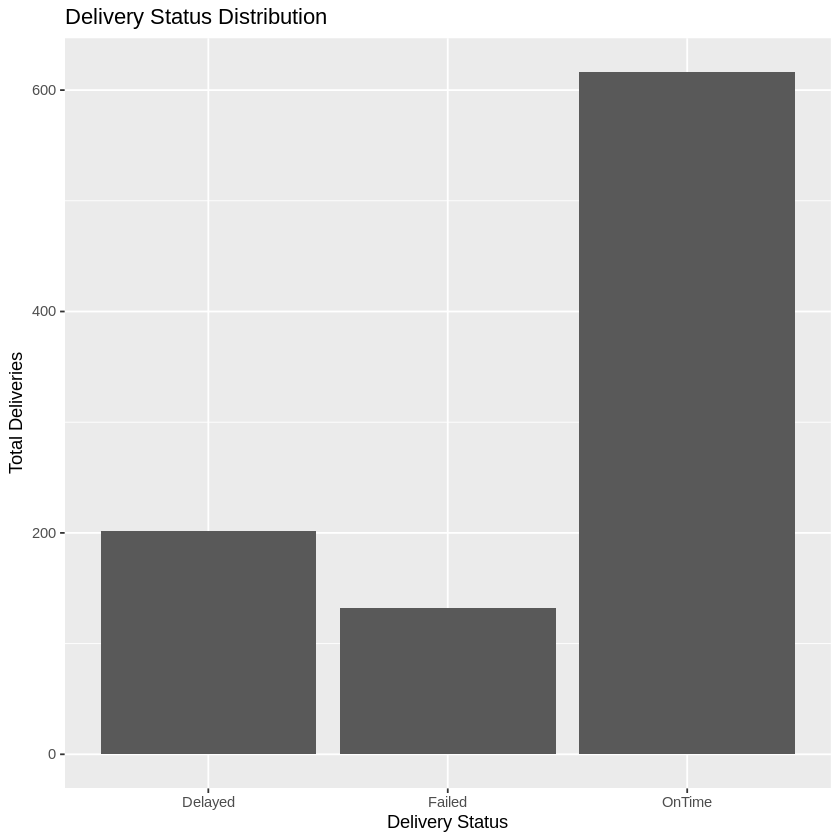

In [15]:
ggplot(delivery_status_summary, aes(x = delivery_status, y = total_deliveries)) +
  geom_bar(stat = "identity") +
  labs(
    title = "Delivery Status Distribution",
    x = "Delivery Status",
    y = "Total Deliveries"
  )

In [16]:
hub_performance <- deliveries %>%
  left_join(hubs, by = "hub_id") %>%
  group_by(hub_name, zone) %>%
  summarise(
    total_deliveries = n(),
    problem_deliveries = sum(delivery_status != "Completed", na.rm = TRUE),
    average_rating = mean(customer_rating_post_delivery, na.rm = TRUE),
    average_route_overrides = mean(manual_route_override_count, na.rm = TRUE)
  ) %>%
  arrange(desc(problem_deliveries))

hub_performance

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by hub_name and zone.
ℹ Output is grouped by hub_name.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(hub_name, zone))` for per-operation grouping
  (`?dplyr::dplyr_by`) instead.


hub_name,zone,total_deliveries,problem_deliveries,average_rating,average_route_overrides
<chr>,<chr>,<int>,<int>,<dbl>,<dbl>
North Exchange,North,136,136,3.840593,1.0294118
Midtown Relay,Central,128,128,3.884560,1.1093750
West Gate,West,127,127,3.915476,0.8740157
East Dock,East,119,119,3.895862,0.8907563
Central Core,Central,115,115,3.669558,0.9478261
Riverside Hub,Riverside,115,115,3.881858,1.0521739
South Link,South,106,106,3.950952,0.9150943
Airport Hub,Airport,104,104,3.882136,0.9134615


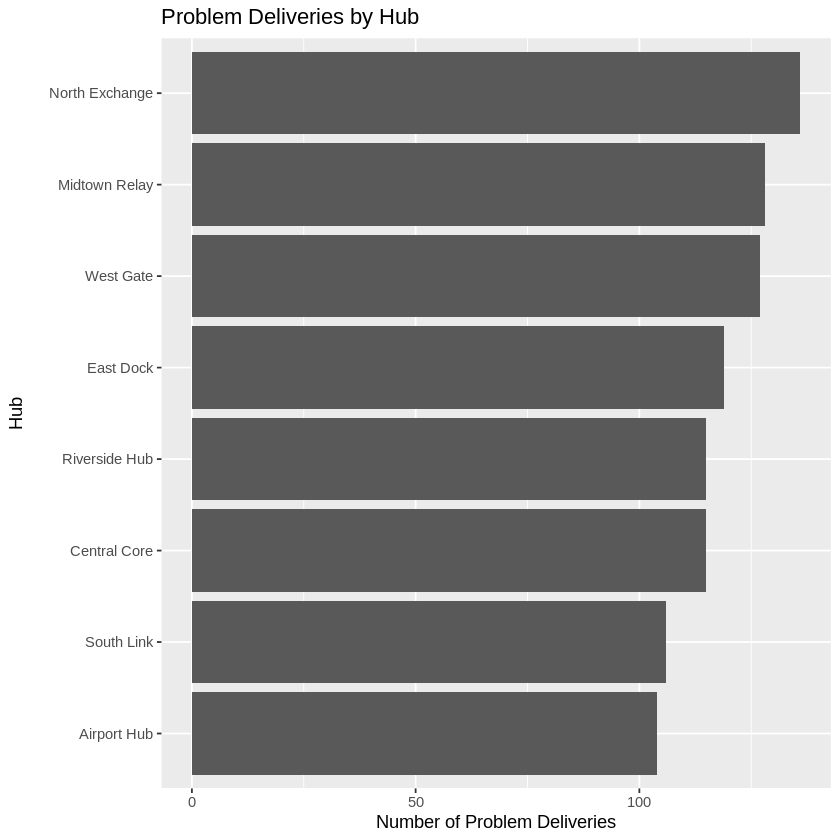

In [17]:
ggplot(hub_performance, aes(x = reorder(hub_name, problem_deliveries),
                            y = problem_deliveries)) +
  geom_bar(stat = "identity") +
  coord_flip() +
  labs(
    title = "Problem Deliveries by Hub",
    x = "Hub",
    y = "Number of Problem Deliveries"
  )

In [18]:
complaints_customer_type <- complaints %>%
  left_join(customers, by = "customer_id") %>%
  group_by(customer_type) %>%
  summarise(total_complaints = n()) %>%
  arrange(desc(total_complaints))

complaints_customer_type

customer_type,total_complaints
<chr>,<int>
Consumer,242
SME,50
Enterprise,28


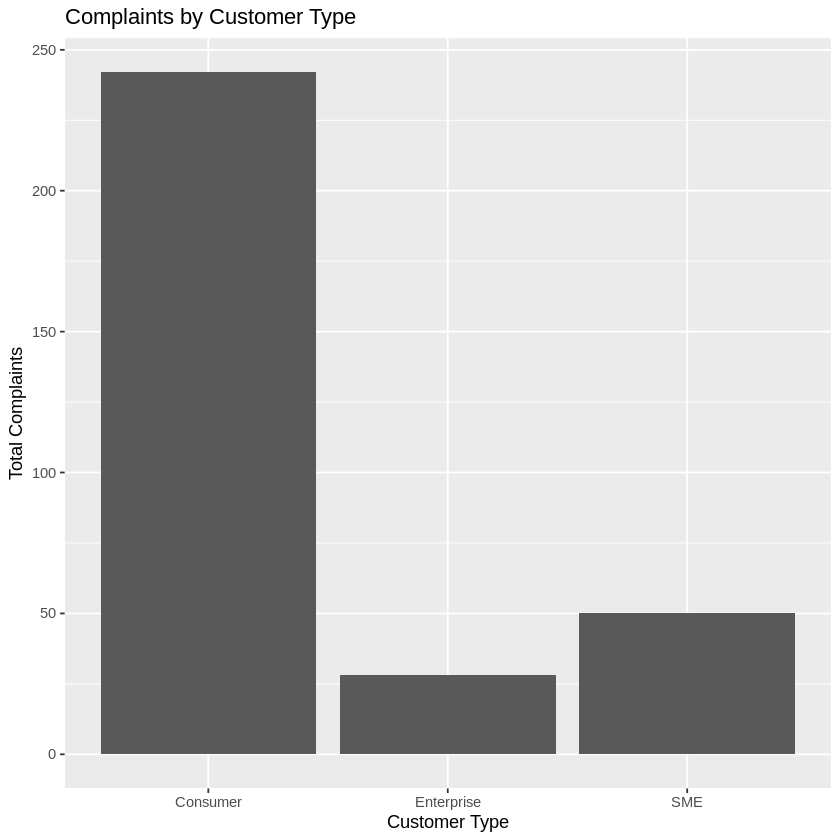

In [19]:
ggplot(complaints_customer_type, aes(x = customer_type, y = total_complaints)) +
  geom_bar(stat = "identity") +
  labs(
    title = "Complaints by Customer Type",
    x = "Customer Type",
    y = "Total Complaints"
  )

In [20]:
complaints_zone <- complaints %>%
  left_join(customers, by = "customer_id") %>%
  group_by(home_zone) %>%
  summarise(total_complaints = n()) %>%
  arrange(desc(total_complaints))

complaints_zone

home_zone,total_complaints
<chr>,<int>
SOUTH,33
CENTRAL,24
North,24
RiverSide,24
East,23
Riverside,21
north,21
Airport,19
NORTH,19


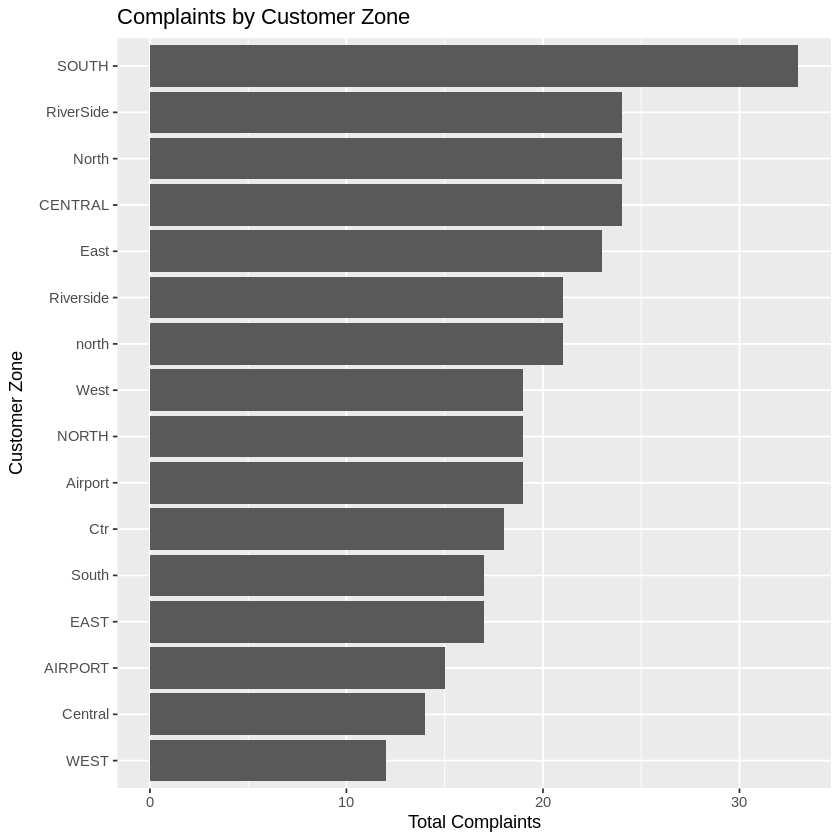

In [21]:
ggplot(complaints_zone, aes(x = reorder(home_zone, total_complaints),
                            y = total_complaints)) +
  geom_bar(stat = "identity") +
  coord_flip() +
  labs(
    title = "Complaints by Customer Zone",
    x = "Customer Zone",
    y = "Total Complaints"
  )

In [22]:
route_override_summary <- deliveries %>%
  left_join(hubs, by = "hub_id") %>%
  group_by(hub_name, zone) %>%
  summarise(
    total_route_overrides = sum(manual_route_override_count, na.rm = TRUE),
    average_route_overrides = mean(manual_route_override_count, na.rm = TRUE)
  ) %>%
  arrange(desc(total_route_overrides))

route_override_summary

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by hub_name and zone.
ℹ Output is grouped by hub_name.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(hub_name, zone))` for per-operation grouping
  (`?dplyr::dplyr_by`) instead.


hub_name,zone,total_route_overrides,average_route_overrides
<chr>,<chr>,<dbl>,<dbl>
Midtown Relay,Central,142,1.1093750
North Exchange,North,140,1.0294118
Riverside Hub,Riverside,121,1.0521739
West Gate,West,111,0.8740157
Central Core,Central,109,0.9478261
East Dock,East,106,0.8907563
South Link,South,97,0.9150943
Airport Hub,Airport,95,0.9134615


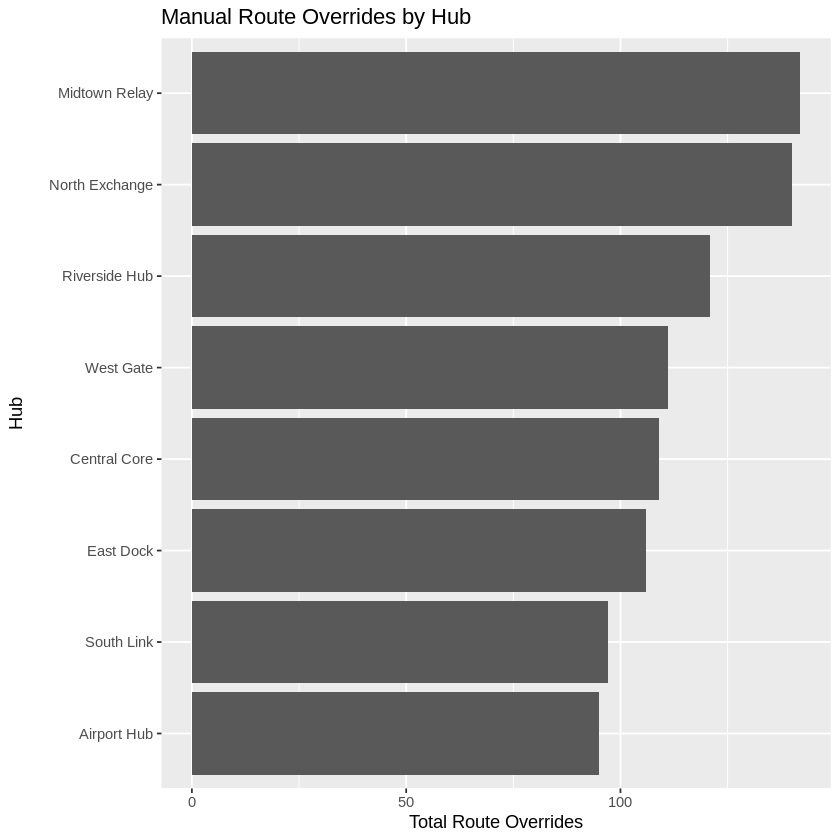

In [23]:
ggplot(route_override_summary, aes(x = reorder(hub_name, total_route_overrides),
                                   y = total_route_overrides)) +
  geom_bar(stat = "identity") +
  coord_flip() +
  labs(
    title = "Manual Route Overrides by Hub",
    x = "Hub",
    y = "Total Route Overrides"
  )

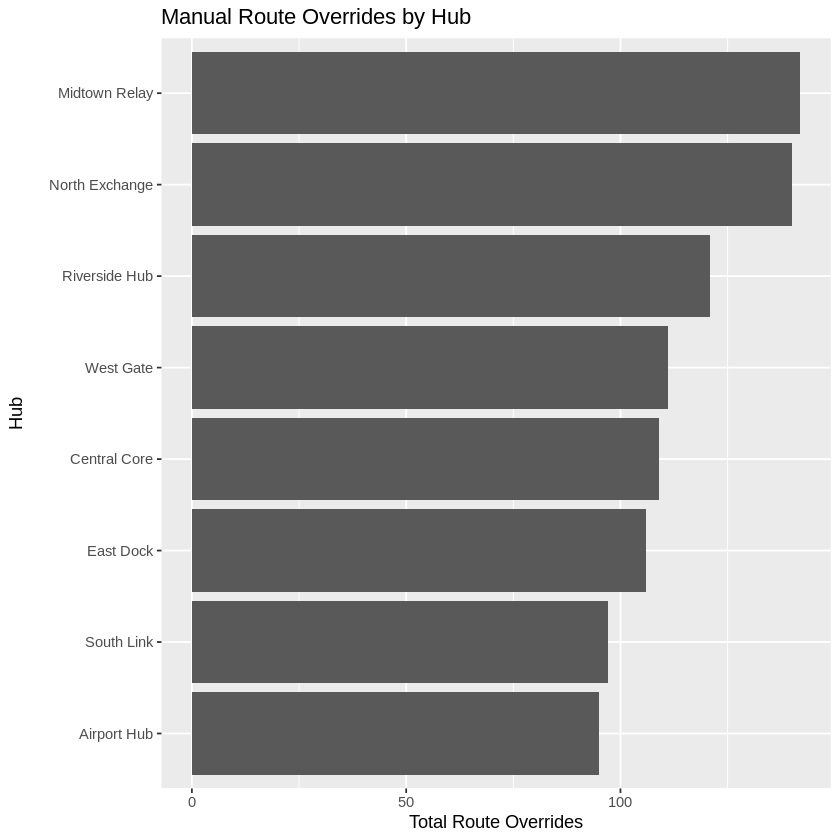

In [24]:
ggplot(route_override_summary, aes(x = reorder(hub_name, total_route_overrides),
                                   y = total_route_overrides)) +
  geom_bar(stat = "identity") +
  coord_flip() +
  labs(
    title = "Manual Route Overrides by Hub",
    x = "Hub",
    y = "Total Route Overrides"
  )

In [25]:
driver_incident_analysis <- deliveries %>%
  left_join(incidents, by = "delivery_id") %>%
  left_join(drivers, by = "driver_id") %>%
  group_by(driver_id, base_zone, employment_type, training_score, years_experience) %>%
  summarise(total_incidents = sum(!is.na(incident_id))) %>%
  arrange(desc(total_incidents))

driver_incident_analysis

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by driver_id, base_zone, employment_type,
  training_score, and years_experience.
ℹ Output is grouped by driver_id, base_zone, employment_type, and
  training_score.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(driver_id, base_zone, employment_type, training_score,
  years_experience))` for per-operation grouping (`?dplyr::dplyr_by`) instead.


driver_id,base_zone,employment_type,training_score,years_experience,total_incidents
<chr>,<chr>,<chr>,<dbl>,<dbl>,<int>
D039,AIRPORT,Contract,86.1,7,7
D087,north,Contract,73.3,13,6
D004,Airport,PartTime,88.9,13,5
D026,NORTH,PartTime,84.9,4,5
D132,South,Contract,77.6,8,5
D146,Airport,Contract,NA,1,5
D002,Central,FullTime,42.4,4,4
D032,East,PartTime,81.5,6,4
D037,north,PartTime,63.9,7,4


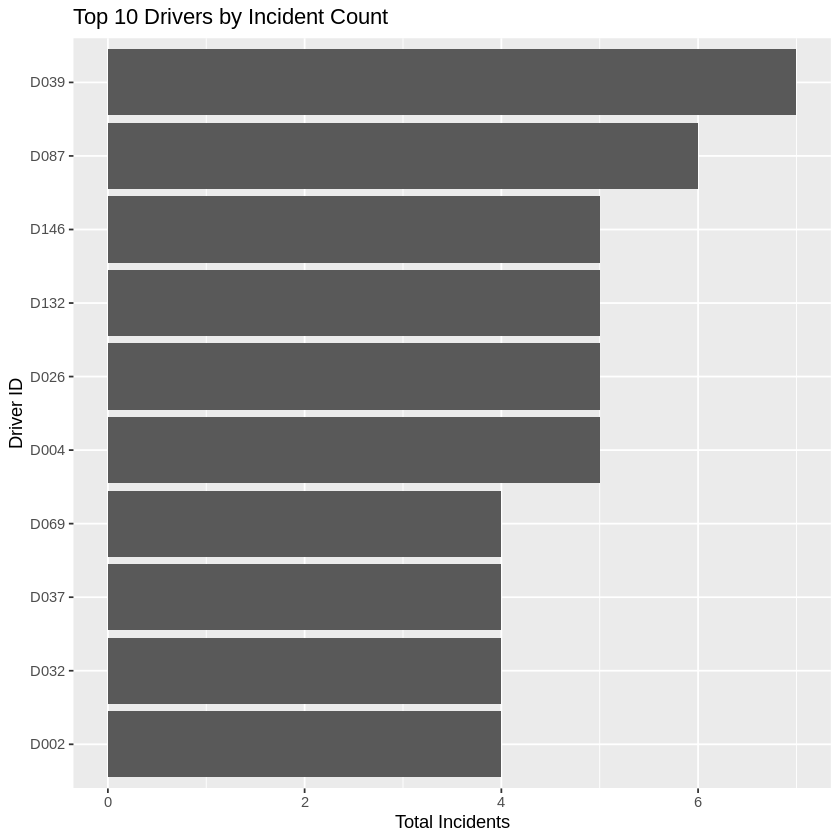

In [26]:
top_driver_incidents <- head(driver_incident_analysis, 10)

ggplot(top_driver_incidents, aes(x = reorder(driver_id, total_incidents),
                                 y = total_incidents)) +
  geom_bar(stat = "identity") +
  coord_flip() +
  labs(
    title = "Top 10 Drivers by Incident Count",
    x = "Driver ID",
    y = "Total Incidents"
  )

In [27]:
correlation_data <- deliveries %>%
  select(customer_rating_post_delivery, manual_route_override_count) %>%
  na.omit()

cor(correlation_data)

,customer_rating_post_delivery,manual_route_override_count
customer_rating_post_delivery,1.00000000,-0.05990295
manual_route_override_count,-0.05990295,1.00000000


`geom_smooth()` using formula = 'y ~ x'


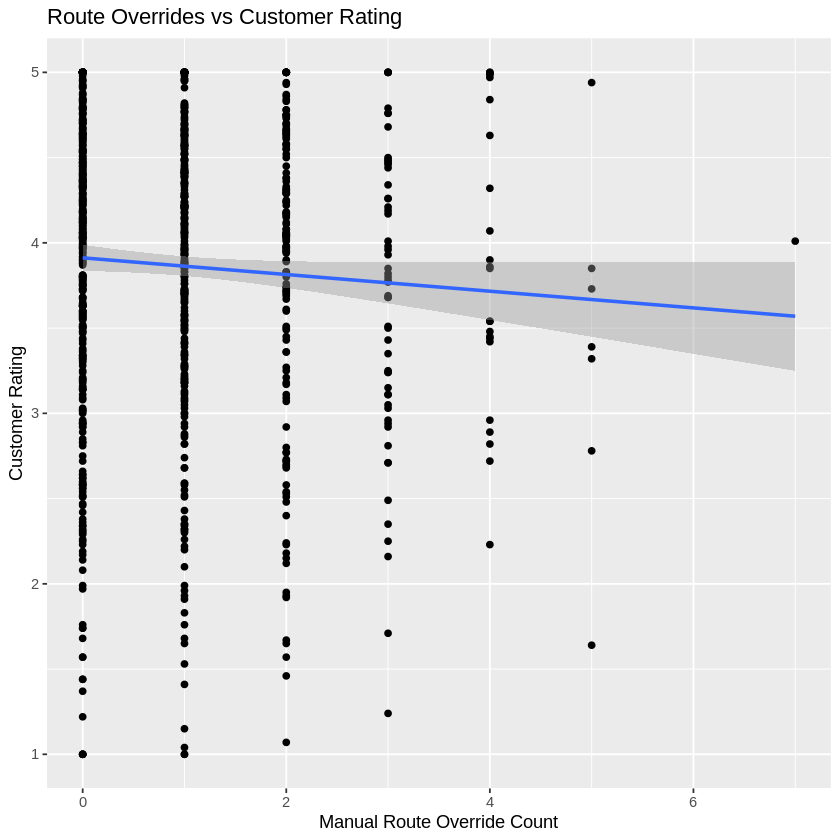

In [28]:
ggplot(correlation_data, aes(x = manual_route_override_count,
                             y = customer_rating_post_delivery)) +
  geom_point() +
  geom_smooth(method = "lm") +
  labs(
    title = "Route Overrides vs Customer Rating",
    x = "Manual Route Override Count",
    y = "Customer Rating"
  )

In [31]:
driver_incident_correlation <- driver_incident_analysis %>%
  ungroup() %>%
  select(training_score, total_incidents) %>%
  mutate(
    training_score = as.numeric(training_score),
    total_incidents = as.numeric(total_incidents)
  ) %>%
  na.omit()

head(driver_incident_correlation)

training_score,total_incidents
<dbl>,<dbl>
86.1,7
73.3,6
88.9,5
84.9,5
77.6,5
42.4,4


`geom_smooth()` using formula = 'y ~ x'


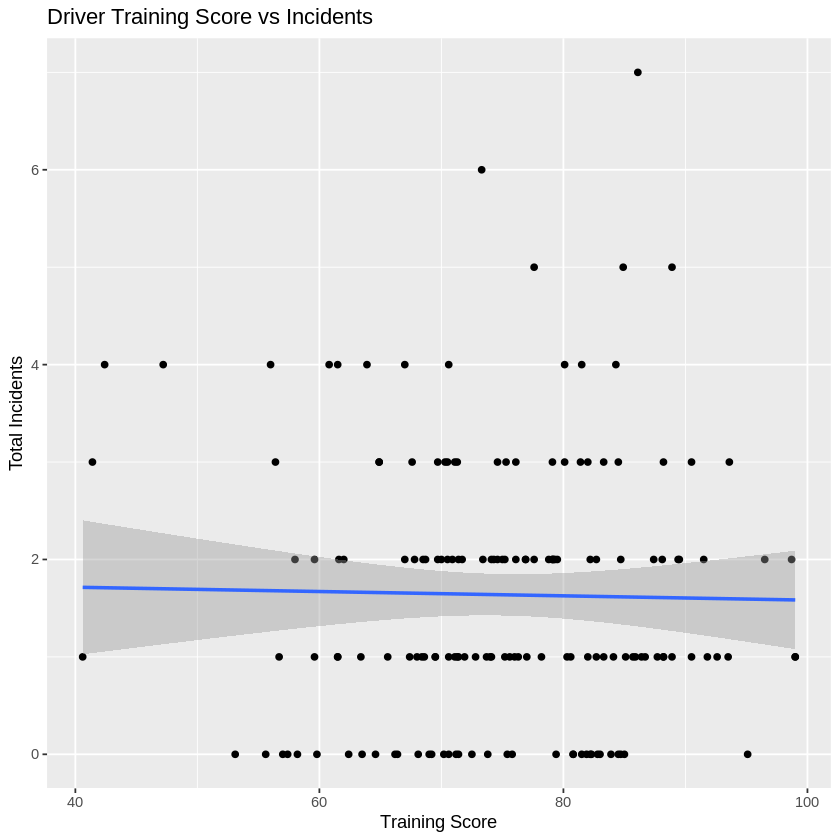

In [32]:
ggplot(driver_incident_correlation, aes(x = training_score, y = total_incidents)) +
  geom_point() +
  geom_smooth(method = "lm") +
  labs(
    title = "Driver Training Score vs Incidents",
    x = "Training Score",
    y = "Total Incidents"
  )

In [33]:
write_csv(rating_summary, "rating_summary.csv")
write_csv(driver_training_summary, "driver_training_summary.csv")
write_csv(delivery_status_summary, "delivery_status_summary.csv")
write_csv(hub_performance, "hub_performance.csv")
write_csv(complaints_customer_type, "complaints_customer_type.csv")
write_csv(complaints_zone, "complaints_zone.csv")
write_csv(route_override_summary, "route_override_summary.csv")
write_csv(driver_incident_analysis, "driver_incident_analysis.csv")